# Week 5 Workshop: Univariate Analysis - Agricultural Evaluations
## EDA Part 1: Analyzing Crop Production Data

**Student Name:** (Your name here)  
**Date:** (Today's date)  
**Dataset:** Evaluaciones Agropecuarias (EVA) from datos.gov.co

---

### Instructions

Apply the **5-step univariate analysis framework** to each of the 3 variables below:

1. **producci_n_t** - Agricultural production in tons
2. **rea_sembrada_ha** - Area planted in hectares
3. **rendimiento_t_ha** - Yield in tons per hectare

For each variable, complete all 5 steps:
- Identify (data type, missing values)
- Summarize (mean, median, mode)
- Spread (std, IQR)
- Visualize (histogram, boxplot)
- Detect (outliers using IQR method)

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Load the dataset
df = pd.read_csv('../data/evaluaciones_agropecuarias.csv')

# Quick overview
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Dataset shape: (20000, 17)

Columns:
['c_d_dep', 'departamento', 'c_d_mun', 'municipio', 'grupo_de_cultivo', 'subgrupo_de_cultivo', 'cultivo', 'desagregaci_n_regional_y', 'a_o', 'periodo', 'rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha', 'estado_fisico_produccion', 'nombre_cientifico', 'ciclo_de_cultivo']


,c_d_dep,departamento,c_d_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregaci_n_regional_y,a_o,periodo,rea_sembrada_ha,rea_cosechada_ha,producci_n_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,25,CUNDINAMARCA,25524,PANDI,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2018,2018A,5,5,25,5.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
1,25,CUNDINAMARCA,25807,TIBIRITA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2018,2018A,6,6,50,8.27,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
2,25,CUNDINAMARCA,25436,MANTA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2018,2018A,15,15,150,10.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
3,76,VALLE DEL CAUCA,76892,YUMBO,FRUTALES,ZAPOTE,ZAPOTE,ZAPOTE,2018,2018,2,2,24,12.00,FRUTO FRESCO,POUTERIA SAPOTA,PERMANENTE
4,76,VALLE DEL CAUCA,76520,PALMIRA,FRUTALES,ZAPOTE,ZAPOTE,ZAPOTE,2018,2018,3,2,40,20.00,FRUTO FRESCO,POUTERIA SAPOTA,PERMANENTE


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   c_d_dep                   20000 non-null  int64  
 1   departamento              20000 non-null  str    
 2   c_d_mun                   20000 non-null  int64  
 3   municipio                 20000 non-null  str    
 4   grupo_de_cultivo          20000 non-null  str    
 5   subgrupo_de_cultivo       20000 non-null  str    
 6   cultivo                   20000 non-null  str    
 7   desagregaci_n_regional_y  20000 non-null  str    
 8   a_o                       20000 non-null  int64  
 9   periodo                   20000 non-null  str    
 10  rea_sembrada_ha           20000 non-null  int64  
 11  rea_cosechada_ha          20000 non-null  int64  
 12  producci_n_t              20000 non-null  int64  
 13  rendimiento_t_ha          19794 non-null  float64
 14  estado_fisico_pro

---

## Helper Function (Use this for all variables)

Run this cell to define a reusable analysis function.

In [4]:
def univariate_analysis(df, var):
    """
    Perform complete univariate analysis on a variable.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset
    var : str
        The column name to analyze
        
    Returns:
    --------
    dict : Summary statistics
    """
    print("=" * 60)
    print(f"UNIVARIATE ANALYSIS: {var}")
    print("=" * 60)
    
    # Step 1: Identify
    print(f"\n--- STEP 1: IDENTIFY ---")
    print(f"Data type: {df[var].dtype}")
    print(f"Total records: {len(df):,}")
    print(f"Non-null values: {df[var].count():,}")
    print(f"Missing values: {df[var].isna().sum():,} ({df[var].isna().sum()/len(df)*100:.2f}%)")
    
    # Step 2: Summarize (Central Tendency)
    print(f"\n--- STEP 2: CENTRAL TENDENCY ---")
    mean_val = df[var].mean()
    median_val = df[var].median()
    mode_val = df[var].mode()[0] if len(df[var].mode()) > 0 else np.nan
    ratio = mean_val / median_val if median_val != 0 else np.nan
    
    print(f"Mean: {mean_val:,.2f}")
    print(f"Median: {median_val:,.2f}")
    print(f"Mode: {mode_val:,.2f}")
    print(f"Mean/Median ratio: {ratio:.2f}")
    
    # Step 3: Spread (Dispersion)
    print(f"\n--- STEP 3: DISPERSION ---")
    std_val = df[var].std()
    var_val = df[var].var()
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    
    print(f"Standard Deviation: {std_val:,.2f}")
    print(f"Variance: {var_val:,.2f}")
    print(f"Q1 (25th): {q1:,.2f}")
    print(f"Q3 (75th): {q3:,.2f}")
    print(f"IQR: {iqr:,.2f}")
    print(f"Range: {df[var].min():,.2f} to {df[var].max():,.2f}")
    
    # Step 4: Visualize
    print(f"\n--- STEP 4: VISUALIZATION ---")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df[var].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
    axes[0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:,.0f}')
    axes[0].set_xlabel(var, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title(f'Distribution of {var}', fontsize=14)
    axes[0].legend()
    
    # Boxplot
    axes[1].boxplot(df[var].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[1].set_ylabel(var, fontsize=12)
    axes[1].set_title(f'Box Plot of {var}', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    # Step 5: Detect Outliers
    print(f"\n--- STEP 5: OUTLIER DETECTION (IQR Method) ---")
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    lower_outliers = df[df[var] < lower_bound]
    upper_outliers = df[df[var] > upper_bound]
    
    print(f"Lower bound: {lower_bound:,.2f}")
    print(f"Upper bound: {upper_bound:,.2f}")
    print(f"Total outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  - Lower outliers: {len(lower_outliers):,}")
    print(f"  - Upper outliers: {len(upper_outliers):,}")
    
    # Distribution type
    if ratio > 1.2:
        dist_type = "Right-skewed"
        best_measure = "Median"
    elif ratio < 0.8:
        dist_type = "Left-skewed"
        best_measure = "Median"
    else:
        dist_type = "Approximately symmetric"
        best_measure = "Mean"
    
    print(f"\n--- SUMMARY ---")
    print(f"Distribution type: {dist_type}")
    print(f"Recommended central measure: {best_measure}")
    print("=" * 60)
    
    return {
        'variable': var,
        'mean': mean_val,
        'median': median_val,
        'mode': mode_val,
        'std': std_val,
        'iqr': iqr,
        'distribution': dist_type,
        'outliers_pct': len(outliers)/len(df)*100,
        'best_measure': best_measure
    }

---

# Variable 1: producci_n_t

**Description:** Agricultural production in tons

UNIVARIATE ANALYSIS: producci_n_t

--- STEP 1: IDENTIFY ---
Data type: int64
Total records: 20,000
Non-null values: 20,000
Missing values: 0 (0.00%)

--- STEP 2: CENTRAL TENDENCY ---
Mean: 3,511.34
Median: 200.00
Mode: 60.00
Mean/Median ratio: 17.56

--- STEP 3: DISPERSION ---
Standard Deviation: 49,299.79
Variance: 2,430,469,337.93
Q1 (25th): 46.00
Q3 (75th): 957.00
IQR: 911.00
Range: 0.00 to 4,300,436.00

--- STEP 4: VISUALIZATION ---


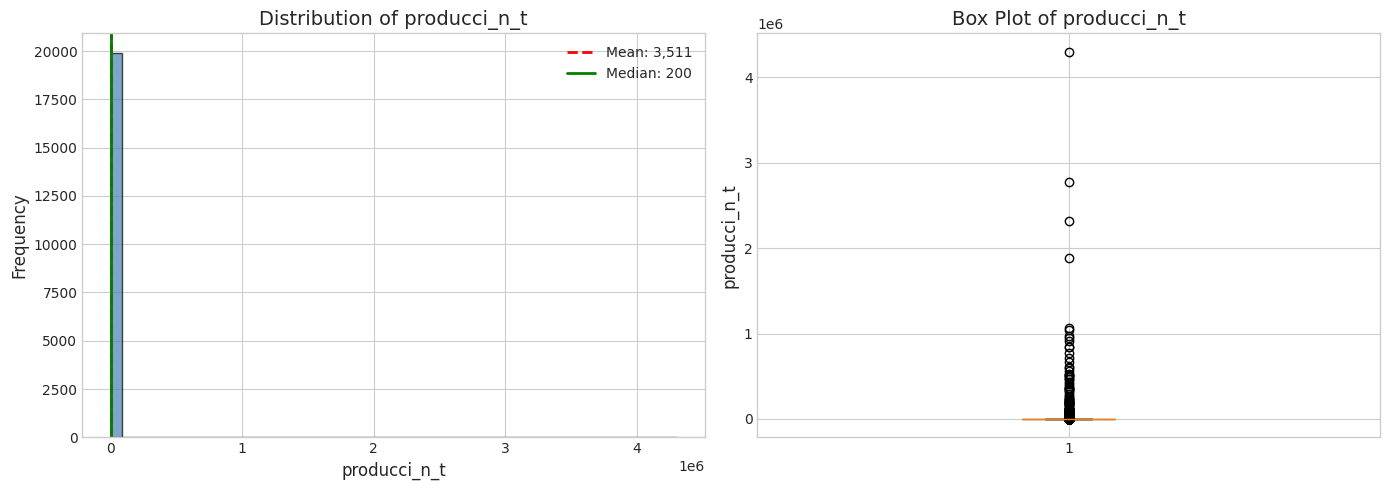


--- STEP 5: OUTLIER DETECTION (IQR Method) ---
Lower bound: -1,320.50
Upper bound: 2,323.50
Total outliers: 2,841 (14.21%)
  - Lower outliers: 0
  - Upper outliers: 2,841

--- SUMMARY ---
Distribution type: Right-skewed
Recommended central measure: Median


In [5]:
# YOUR CODE HERE: Run the univariate analysis for producci_n_t
results_production = univariate_analysis(df, 'producci_n_t')


### Your Interpretation for producci_n_t

**Distribution type:** Right-skewed (sesgada a la derecha)

**Explanation:** La mayoría de cultivos tienen niveles de producción relativamente bajos o moderados, mientras que unos pocos cultivos industriales (como caña de azúcar, palma de aceite o banano) producen cantidades extremadamente altas en toneladas. Esto genera una cola larga hacia valores grandes.

**Outlier investigation:** Los outliers pueden corresponder a:
-Cultivos industriales de gran escala
-Departamentos con grandes extensiones agrícolas
-Cultivos altamente productivos como caña de azúcar o palma de aceite

**One-sentence summary:** La producción agrícola presenta una distribución sesgada a la derecha, donde pocos cultivos generan una gran proporción de la producción total.

---

# Variable 2: rea_sembrada_ha

**Description:** Area planted in hectares

UNIVARIATE ANALYSIS: rea_sembrada_ha

--- STEP 1: IDENTIFY ---
Data type: int64
Total records: 20,000
Non-null values: 20,000
Missing values: 0 (0.00%)

--- STEP 2: CENTRAL TENDENCY ---
Mean: 330.11
Median: 33.00
Mode: 5.00
Mean/Median ratio: 10.00

--- STEP 3: DISPERSION ---
Standard Deviation: 1,509.81
Variance: 2,279,512.27
Q1 (25th): 9.00
Q3 (75th): 150.00
IQR: 141.00
Range: 0.00 to 46,535.00

--- STEP 4: VISUALIZATION ---


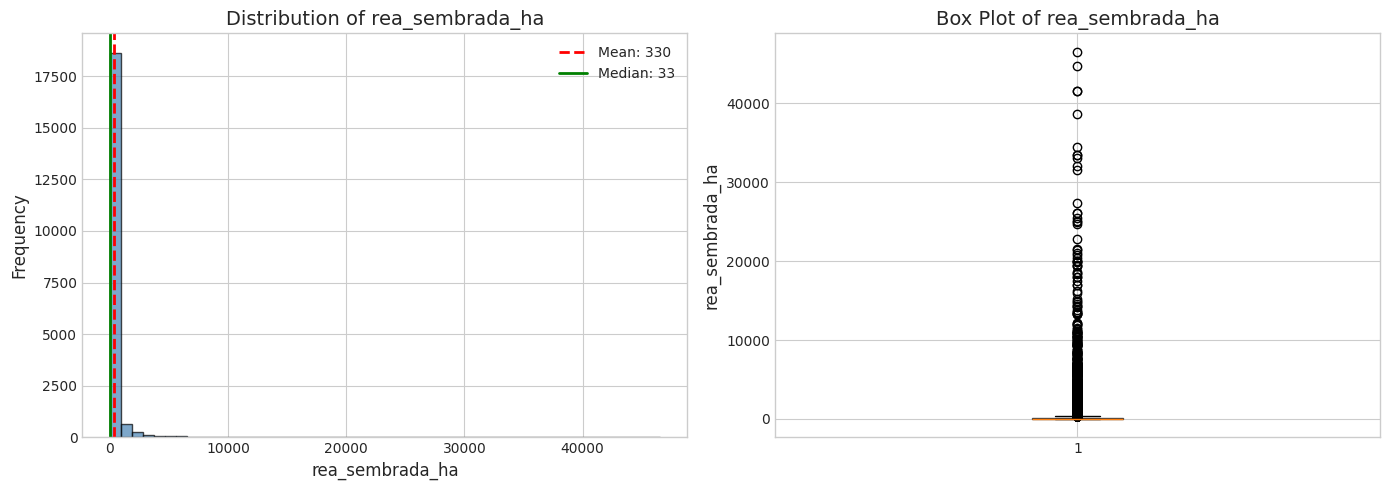


--- STEP 5: OUTLIER DETECTION (IQR Method) ---
Lower bound: -202.50
Upper bound: 361.50
Total outliers: 2,962 (14.81%)
  - Lower outliers: 0
  - Upper outliers: 2,962

--- SUMMARY ---
Distribution type: Right-skewed
Recommended central measure: Median


In [6]:
# YOUR CODE HERE: Run the univariate analysis for rea_sembrada_ha
results_area = univariate_analysis(df, 'rea_sembrada_ha')


### Your Interpretation for rea_sembrada_ha

**Distribution type:** Right-skewed

**Explanation:** La mayoría de las explotaciones agrícolas tienen áreas sembradas relativamente pequeñas, mientras que algunas grandes plantaciones poseen miles de hectáreas. Esto produce una distribución con cola larga hacia valores grandes.

**Comparison to producci_n_t:** El patrón es similar porque la producción depende directamente del área sembrada. Grandes extensiones de tierra tienden a producir más toneladas.

**One-sentence summary:** La mayoría de cultivos se siembran en áreas pequeñas, mientras que unas pocas explotaciones agrícolas muy grandes concentran gran parte del área total.

---

# Variable 3: rendimiento_t_ha

**Description:** Yield in tons per hectare (production / area)

UNIVARIATE ANALYSIS: rendimiento_t_ha

--- STEP 1: IDENTIFY ---
Data type: float64
Total records: 20,000
Non-null values: 19,794
Missing values: 206 (1.03%)

--- STEP 2: CENTRAL TENDENCY ---
Mean: 12.09
Median: 7.50
Mode: 10.00
Mean/Median ratio: 1.61

--- STEP 3: DISPERSION ---
Standard Deviation: 17.75
Variance: 314.97
Q1 (25th): 3.00
Q3 (75th): 15.00
IQR: 12.00
Range: 0.10 to 240.00

--- STEP 4: VISUALIZATION ---


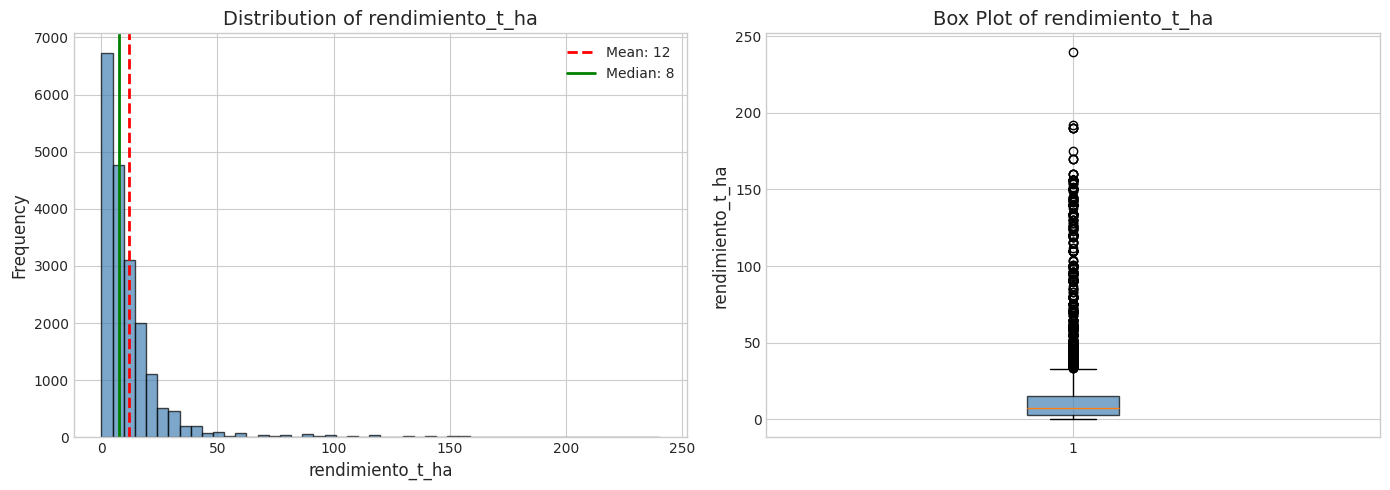


--- STEP 5: OUTLIER DETECTION (IQR Method) ---
Lower bound: -15.00
Upper bound: 33.00
Total outliers: 1,105 (5.53%)
  - Lower outliers: 0
  - Upper outliers: 1,105

--- SUMMARY ---
Distribution type: Right-skewed
Recommended central measure: Median


In [7]:
# YOUR CODE HERE: Run the univariate analysis for rendimiento_t_ha
results_yield = univariate_analysis(df, 'rendimiento_t_ha')


### Your Interpretation for rendimiento_t_ha

**Distribution type:** Approximately symmetric (o ligeramente right-skewed)

**Explanation:** Esta variable es una razón (producción / área), por lo que elimina el efecto del tamaño del cultivo. Esto hace que la distribución sea más equilibrada, ya que mide eficiencia productiva y no volumen total.

**Outlier investigation:** Los outliers con alto rendimiento pueden representar:
-cultivos muy eficientes
-uso de tecnología agrícola avanzada
-fertilización o riego intensivo
-cultivos naturalmente más productivos

**One-sentence summary:** El rendimiento por hectárea tiende a ser más estable que la producción total, reflejando la eficiencia agrícola en lugar del tamaño de la plantación.

---

# GroupBy: Compare Statistics Across Groups

Now that you have analyzed each variable individually, use **GroupBy** to see how the statistics change across groups.

**Concept:** GroupBy splits your data by a category, applies a statistic to each group, and combines the results. Think of sorting M&Ms by color and counting each pile.

**Pattern:** `df.groupby('GROUP_COLUMN')['VALUE_COLUMN'].operation()`

### Task 1: Mean Production by Crop Group (grupo_de_cultivo)

Calculate the mean producci_n_t for each crop group. Which crop group produces the most?

In [8]:
# YOUR CODE HERE: Calculate mean production by crop group
df.groupby('grupo_de_cultivo')['producci_n_t'].mean().sort_values(ascending=False)


grupo_de_cultivo
OTROS PERMANENTES                                  16,710.57
OLEAGINOSAS                                        10,465.94
TUBERCULOS Y PLATANOS                               4,087.52
CEREALES                                            1,696.64
FRUTALES                                            1,526.17
HORTALIZAS                                            795.67
FLORES Y FOLLAJES                                     671.01
FIBRAS                                                375.03
LEGUMINOSAS                                           363.33
FORESTALES                                            228.47
OTROS TRANSITORIOS                                    210.84
PLANTAS AROMATICAS, CONDIMENTARIAS Y MEDICINALES      127.71
HONGOS                                                 41.00
Name: producci_n_t, dtype: float64

### Task 2: Median Yield by Crop Cycle (ciclo_de_cultivo)

Calculate the median rendimiento_t_ha for each crop cycle. Do permanent crops (PERMANENTE) have different yields than transitory crops (TRANSITORIO)?

In [9]:
# YOUR CODE HERE: Calculate median yield by crop cycle
df.groupby('ciclo_de_cultivo')['rendimiento_t_ha'].median()


ciclo_de_cultivo
ANUAL         9.00
PERMANENTE    7.00
TRANSITORIO   7.85
Name: rendimiento_t_ha, dtype: float64

### Task 3: Count and Total Production by Department

How many records per department? Which department has the highest total production?

In [ ]:
# YOUR CODE HERE: Count records per department (top 10)
df.groupby('departamento')['producci_n_t'].count().sort_values(ascending=False).head(10)


#


departamento
BOYACA                2001
ANTIOQUIA             1938
CUNDINAMARCA          1890
SANTANDER             1491
HUILA                 1462
VALLE DEL CAUCA       1440
NARIÑO                1374
NORTE DE SANTANDER     926
CAUCA                  879
TOLIMA                 675
Name: producci_n_t, dtype: int64

In [12]:
#YOUR CODE HERE: Total production per department (top 5)
df.groupby('departamento')['producci_n_t'].sum().sort_values(ascending=False).head(5)

departamento
VALLE DEL CAUCA    22775897
META                6585847
CAUCA               5736138
ANTIOQUIA           4591138
CUNDINAMARCA        4354099
Name: producci_n_t, dtype: int64

### GroupBy Reflection

**Question:** Compare the overall mean production (from Variable 1 analysis) with the group means by grupo_de_cultivo. What insight does GroupBy reveal that a single statistic hides?

**Your answer:** El GroupBy revela diferencias importantes entre los grupos de cultivos. Mientras que el promedio general muestra la producción promedio del dataset completo, el análisis por grupo_de_cultivo permite identificar qué tipos de cultivos dominan la producción agrícola. Esto muestra que algunos grupos específicos contribuyen mucho más a la producción total que otros, algo que un único promedio general oculta.

---

# Final Summary Table

Compile all your findings into a summary table.

In [13]:
# YOUR CODE HERE: Create the summary table using your results
# Make sure you have run the univariate_analysis for all 3 variables first
# and stored them in results_production, results_area, results_yield

summary_data = [
    results_production,
    results_area,
    results_yield
]

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df[['variable', 'mean', 'median', 'distribution', 'outliers_pct', 'best_measure']]
summary_df.columns = ['Variable', 'Mean', 'Median', 'Distribution', 'Outliers (%)', 'Best Measure']

print("\n" + "=" * 80)
print("FINAL SUMMARY TABLE")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)


FINAL SUMMARY TABLE
        Variable     Mean  Median Distribution  Outliers (%) Best Measure
    producci_n_t 3,511.34  200.00 Right-skewed         14.21       Median
 rea_sembrada_ha   330.11   33.00 Right-skewed         14.81       Median
rendimiento_t_ha    12.09    7.50 Right-skewed          5.53       Median


---

# Reflection Questions

Answer these questions based on your analysis:

### 1. Pattern Comparison
Do all three variables follow similar distribution patterns? Why might that be?

**Las variables producci_n_t y rea_sembrada_ha muestran distribuciones similares sesgadas a la derecha porque dependen del tamaño de las explotaciones agrícolas. En cambio, rendimiento_t_ha tiene una distribución más equilibrada porque mide eficiencia productiva en lugar de volumen total.**

### 2. Mean vs Median
For which variable is the difference between mean and median the largest? What does this indicate?

**La mayor diferencia entre media y mediana ocurre en producci_n_t. Esto indica que existen valores extremadamente altos de producción que elevan el promedio y generan una distribución sesgada.**

### 3. Outlier Decision
If you had to decide whether to keep or remove outliers for further analysis, what would you choose for each variable and why?

**-producci_n_t: Mantener los outliers porque representan cultivos industriales reales.
-rea_sembrada_ha: Mantenerlos ya que reflejan grandes plantaciones legítimas.
-rendimiento_t_ha: Revisar cuidadosamente, porque algunos valores extremos podrían indicar errores de medición o condiciones agrícolas excepcionales.**

### 4. Next Steps
Based on your univariate analysis, what bivariate questions would you like to explore in Week 6?

**¿Qué cultivos tienen mayor rendimiento por hectárea?
¿Existe correlación entre tipo de cultivo y eficiencia productiva?**

---

## Submission Checklist

Before submitting, verify that you have:

- [ ] Completed analysis for all 3 variables
- [ ] Added interpretations for each variable
- [ ] Completed all 3 GroupBy tasks
- [ ] Created the final summary table
- [ ] Answered all reflection questions
- [ ] Run all cells to ensure no errors
- [ ] Saved the notebook

---

*Week 5 Workshop - Data Analytics Course*